# UT2 · Sistemas de Aprendizaje Automático + Python — Cuaderno práctico

Este cuaderno acompaña a la parte práctica de la Unidad 2. Recorre NumPy, Pandas (carga, exploración y limpieza), Matplotlib básico, y cierra con un primer vistazo a Scikit-learn.

No hace falta ningún archivo externo: el dataset de ejemplo se genera dentro del propio cuaderno, así que puedes ejecutar todas las celdas de arriba a abajo sin preparación previa.

**Cómo usarlo en clase:** cada bloque tiene primero una celda de práctica guiada (ya resuelta, para seguir el razonamiento) y después, en varios bloques, un mini-reto para que el alumnado lo intente antes de mirar la celda siguiente.

In [1]:
# Si alguna librería falta, descomenta e instala:
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1 · NumPy: de listas a arrays

Empezamos por la base: crear arrays, indexarlos y comparar cómo cambian las operaciones respecto a una lista de Python normal.

In [2]:
precios_lista = [10, 20, 30]
precios_array = np.array(precios_lista)

print("Lista   * 2:", precios_lista * 2)   # repite la secuencia
print("Array   * 2:", precios_array * 2)   # multiplica cada elemento

Lista   * 2: [10, 20, 30, 10, 20, 30]
Array   * 2: [20 40 60]


In [3]:
# Matriz 2D y las tres formas de indexar más usadas
m = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print("Primera fila:      ", m[0])
print("Segunda columna:    ", m[:, 1])
print("Elementos > 5:      ", m[m > 5])
print("Forma de la matriz: ", m.shape)

Primera fila:       [1 2 3]
Segunda columna:     [2 5 8]
Elementos > 5:       [6 7 8 9]
Forma de la matriz:  (3, 3)


In [4]:
puntuaciones = np.array([3, 7, 5, 9, 2, 6, 8, 4, 10, 1])

print("Media:            ", puntuaciones.mean())
print("Desviación típica:", round(puntuaciones.std(), 2))
print("Máximo / mínimo:  ", puntuaciones.max(), "/", puntuaciones.min())

altas_mask = puntuaciones >= 5
print("¿Puntuación alta? ", altas_mask)
print("Puntuaciones altas:", puntuaciones[altas_mask])


Media:             5.5
Desviación típica: 2.87
Máximo / mínimo:   10 / 1
¿Puntuación alta?  [False  True  True  True False  True  True False  True False]
Puntuaciones altas: [ 7  5  9  6  8 10]


### np.where: selección y modificación condicional

In [5]:
# np.where(condición, valor_si_true, valor_si_false) es el "si/si no" vectorizado
etiquetas = np.where(puntuaciones >= 6, "alta", "baja")
print("Etiquetas:", etiquetas)

# también sirve para "recortar" valores por debajo de un mínimo, sin bucles
recortadas = np.where(puntuaciones < 4, 4, puntuaciones)
print("Recortadas (mínimo 4):", recortadas)

Etiquetas: ['baja' 'alta' 'baja' 'alta' 'baja' 'alta' 'alta' 'baja' 'alta' 'baja']
Recortadas (mínimo 4): [ 4  7  5  9  4  6  8  4 10  4]


### Broadcasting: operar arrays de formas distintas

In [6]:
tabla = np.array([[1, 2, 3], [4, 5, 6]])          # 2 filas x 3 columnas
factor_por_columna = np.array([10, 100, 1000])      # 1 fila x 3 columnas

print("tabla * factor_por_columna:\n", tabla * factor_por_columna)
# NumPy "repite" mentalmente factor_por_columna en cada fila de tabla, sin duplicar datos en memoria

tabla * factor_por_columna:
 [[  10  200 3000]
 [  40  500 6000]]


### Funciones para crear arrays

No siempre partimos de una lista: muchas veces necesitamos crear un array "desde cero" con una forma concreta.

In [7]:
# Formas habituales de crear arrays sin escribir los valores a mano
np.random.seed(42)   # fija la semilla: mismos "aleatorios" cada vez que se ejecuta

ceros = np.zeros((2, 3))
unos = np.ones((2, 3))
llenos = np.full((2, 3), 7)
identidad = np.eye(3)
diagonal = np.diag([1, 2, 3])
secuencia = np.arange(0, 10, 2)          # de 0 a 10 (sin incluir), de 2 en 2
espaciado = np.linspace(0, 1, 5)          # 5 valores igualmente repartidos entre 0 y 1
aleatorios_enteros = np.random.randint(0, 10, size=(2, 3))   # enteros aleatorios entre 0 y 9

print("zeros:\n", ceros)
print("full:\n", llenos)
print("eye:\n", identidad)
print("diag:\n", diagonal)
print("arange:", secuencia)
print("linspace:", espaciado)
print("randint:\n", aleatorios_enteros)


zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
full:
 [[7 7 7]
 [7 7 7]]
eye:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
diag:
 [[1 0 0]
 [0 2 0]
 [0 0 3]]
arange: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
randint:
 [[6 3 7]
 [4 6 9]]


### Inspeccionar, reorganizar y combinar arrays

In [8]:
print("shape:", m.shape, " ndim:", m.ndim, " size:", m.size, " dtype:", m.dtype)

# reshape cambia la forma sin cambiar los datos
plano = m.reshape(9)
print("reshape a 1D:", plano)
print("traspuesta:\n", m.T)

# combinar arrays
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("concatenate:", np.concatenate([a, b]))
print("vstack:\n", np.vstack([a, b]))
print("hstack:", np.hstack([a, b]))


shape: (3, 3)  ndim: 2  size: 9  dtype: int64
reshape a 1D: [1 2 3 4 5 6 7 8 9]
traspuesta:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]
concatenate: [1 2 3 4 5 6]
vstack:
 [[1 2 3]
 [4 5 6]]
hstack: [1 2 3 4 5 6]


### Agregados por eje: axis=0 vs. axis=1

In [9]:
horas_semana = np.array([
    [2, 3, 1, 4],   # jugador A: horas jugadas cada semana
    [5, 4, 6, 5],   # jugador B
    [1, 2, 2, 1],   # jugador C
])

print("Total por semana (axis=0):", horas_semana.sum(axis=0))
print("Total por jugador (axis=1):", horas_semana.sum(axis=1))
print("Media semanal por jugador:", horas_semana.mean(axis=1))

Total por semana (axis=0): [ 8  9  9 10]
Total por jugador (axis=1): [10 20  6]
Media semanal por jugador: [2.5 5.  1.5]


### Ordenar arrays

In [10]:
print("Ordenado (menor a mayor):", np.sort(puntuaciones))
print("Ordenado (mayor a menor):  ", np.sort(puntuaciones)[::-1])

orden = np.argsort(puntuaciones)          # índices que ordenarían el array
print("Índices de orden:", orden)
print("Puntuaciones según ese orden:", puntuaciones[orden])

Ordenado (menor a mayor): [ 1  2  3  4  5  6  7  8  9 10]
Ordenado (mayor a menor):   [10  9  8  7  6  5  4  3  2  1]
Índices de orden: [9 4 0 7 2 5 1 6 3 8]
Puntuaciones según ese orden: [ 1  2  3  4  5  6  7  8  9 10]


**Reto rápido:** crea un array `temperaturas` con 7 valores (uno por día de la semana) y calcula cuántos días ha hecho más de 25°. Pista: usa una máscara booleana y `.sum()` (True cuenta como 1).

In [11]:
# Solución del reto
temperaturas = np.array([22, 26, 31, 19, 28, 33, 24])
dias_calurosos = (temperaturas > 25).sum()
print(f"Días con más de 25°: {dias_calurosos}")

Días con más de 25°: 4


### Experimento: bucle Python vs. vectorización

In [12]:
import time

n = 1_000_000
datos = np.random.random(n)

inicio = time.time()
resultado_bucle = [x * 2 for x in datos]
t_bucle = time.time() - inicio

inicio = time.time()
resultado_vector = datos * 2
t_vector = time.time() - inicio

print(f"Bucle Python:  {t_bucle:.4f} s")
print(f"Vectorizado:   {t_vector:.4f} s")
print(f"Vectorizado es aprox. {t_bucle / t_vector:.0f}x más rápido en esta máquina")

Bucle Python:  0.1351 s
Vectorizado:   0.0117 s
Vectorizado es aprox. 12x más rápido en esta máquina


## 2 · Pandas: creamos un dataset de ejemplo

En clase normalmente cargaréis un CSV con `pd.read_csv("archivo.csv")`. Aquí generamos uno en memoria — estadísticas de jugadores de un videojuego online, con nulos y duplicados incluidos a propósito — para poder practicar limpieza sin depender de ningún archivo externo.

In [13]:
plataformas = ["PC", "Consola"]
n = 40

df = pd.DataFrame({
    "jugador_id": range(1, n + 1),
    "plataforma": np.random.choice(plataformas, size=n),
    "horas_jugadas": np.round(np.random.normal(6, 2, size=n), 1),
    "puntuacion": np.round(np.random.normal(6.2, 1.8, size=n), 1),
})

# Ensuciamos el dataset a propósito, como pasa con datos reales
df.loc[[3, 15, 27], "puntuacion"] = np.nan          # algunos nulos
df.loc[[5, 22], "horas_jugadas"] = np.nan
df = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)  # dos filas duplicadas
df["puntuacion"] = df["puntuacion"].clip(0, 10)

df.head()


,jugador_id,plataforma,horas_jugadas,puntuacion
0,1,Consola,7.2,7.3
1,2,Consola,3.0,6.7
2,3,PC,8.3,3.7
3,4,Consola,5.0,NaN
4,5,Consola,7.6,5.2


### Tipos de dato y conversión con astype

In [14]:
print("Tipos de cada columna:")
print(df.dtypes)

df["plataforma"] = df["plataforma"].astype("category")   # menos memoria con pocos valores distintos
print("\nTras convertir plataforma a category:", df["plataforma"].dtype)

Tipos de cada columna:
jugador_id         int64
plataforma           str
horas_jugadas    float64
puntuacion       float64
dtype: object



Tras convertir plataforma a category: category


### Renombrar columnas y el índice

In [15]:
df_renombrado = df.rename(columns={"horas_jugadas": "horas_semana"})
print(df_renombrado.columns.tolist())

df_indexado = df.set_index("jugador_id")   # jugador_id pasa a ser el índice
print(df_indexado.head(2))

df_indexado.reset_index().head(2)          # deshace el cambio: jugador_id vuelve a ser columna

['jugador_id', 'plataforma', 'horas_semana', 'puntuacion']
           plataforma  horas_jugadas  puntuacion
jugador_id                                      
1             Consola            7.2         7.3
2             Consola            3.0         6.7


,jugador_id,plataforma,horas_jugadas,puntuacion
0,1,Consola,7.2,7.3
1,2,Consola,3.0,6.7


### Exploración inicial

Antes de tocar nada, siempre lo mismo: cuántas filas y columnas hay, de qué tipo es cada una, y si hay huecos.

In [16]:
print("Forma del dataset (filas, columnas):", df.shape)
df.info()

Forma del dataset (filas, columnas): (42, 4)
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   jugador_id     42 non-null     int64   
 1   plataforma     42 non-null     category
 2   horas_jugadas  40 non-null     float64 
 3   puntuacion     39 non-null     float64 
dtypes: category(1), float64(2), int64(1)
memory usage: 1.2 KB


In [17]:
df.describe()

,jugador_id,horas_jugadas,puntuacion
count,42.000000,40.000000,39.000000
mean,19.595238,5.665000,6.143590
std,12.115420,2.019844,1.762742
min,1.000000,0.600000,1.500000
25%,9.250000,4.050000,5.050000
50%,19.500000,6.000000,6.700000
75%,29.750000,7.300000,7.300000
max,40.000000,8.400000,8.700000


In [18]:
# Filtrado con máscaras booleanas
alta_habilidad = df[df["puntuacion"] >= 7]
pc_alta_habilidad = df[(df["plataforma"] == "PC") & (df["puntuacion"] >= 7)]

print("Total filas:        ", len(df))
print("Alta habilidad:     ", len(alta_habilidad))
print("PC y alta habilidad:", len(pc_alta_habilidad))


Total filas:         42
Alta habilidad:      12
PC y alta habilidad: 6


### Cuatro formas de seleccionar datos

`df["col"]` para una columna, `.loc` por etiqueta, `.iloc` por posición y `.query()` para condiciones más legibles.

In [19]:
print(df["puntuacion"].head(3))                                        # una columna
print(df.loc[0:2, ["plataforma", "puntuacion"]])                       # .loc: por etiqueta (filas 0 a 2 incluida)
print(df.iloc[0:3, 0:2])                                               # .iloc: por posición
print(df.query("puntuacion >= 8 and plataforma == \'PC\'").head())      # .query(): condición como texto


0    7.3
1    6.7
2    3.7
Name: puntuacion, dtype: float64
  plataforma  puntuacion
0    Consola         7.3
1    Consola         6.7
2         PC         3.7
   jugador_id plataforma
0           1    Consola
1           2    Consola
2           3         PC
    jugador_id plataforma  horas_jugadas  puntuacion
11          12         PC            4.3         8.6
24          25         PC            5.5         8.7
25          26         PC            7.2         8.7
38          39         PC            7.3         8.6


### Ordenar filas

In [20]:
print(df.sort_values("puntuacion", ascending=False).head(3))   # los 3 primeros, de mayor a menor

print("\nTop 5 por nlargest (más directo que ordenar toda la tabla):")
print(df.nlargest(5, "puntuacion")[["jugador_id", "plataforma", "puntuacion"]])

    jugador_id plataforma  horas_jugadas  puntuacion
24          25         PC            5.5         8.7
25          26         PC            7.2         8.7
38          39         PC            7.3         8.6

Top 5 por nlargest (más directo que ordenar toda la tabla):
    jugador_id plataforma  puntuacion
24          25         PC         8.7
25          26         PC         8.7
11          12         PC         8.6
38          39         PC         8.6
12          13    Consola         8.2


### Agrupar y combinar datasets

`groupby` resume el dataset por categorías, y `merge` lo combina con otra tabla relacionada.

In [21]:
resumen_plataforma = df.groupby("plataforma").agg(
    puntuacion_media=("puntuacion", "mean"),
    total_jugadores=("jugador_id", "count"),
)
resumen_plataforma


,puntuacion_media,total_jugadores
plataforma,,
Consola,6.310000,22
PC,5.968421,20


### Agrupar por varias claves, pivot_table y transform

In [22]:
df["nivel"] = pd.cut(df["puntuacion"], bins=[0, 4, 7, 10], labels=["bajo", "medio", "alto"])

print("Media por plataforma y nivel:")
print(df.groupby(["plataforma", "nivel"])["puntuacion"].mean())

print("\nMisma idea en formato tabla cruzada (pivot_table):")
print(df.pivot_table(values="puntuacion", index="nivel", columns="plataforma", aggfunc="mean"))

# transform: pega el resultado del grupo de vuelta en cada fila, sin colapsar el DataFrame
df["media_de_su_plataforma"] = df.groupby("plataforma")["puntuacion"].transform("mean")
df[["jugador_id", "plataforma", "puntuacion", "media_de_su_plataforma"]].head()

Media por plataforma y nivel:
plataforma  nivel
Consola     medio    5.785714
            alto     7.533333
PC          bajo     3.066667
            medio    6.400000
            alto     8.366667
Name: puntuacion, dtype: float64

Misma idea en formato tabla cruzada (pivot_table):
plataforma   Consola        PC
nivel                         
bajo             NaN  3.066667
medio       5.785714  6.400000
alto        7.533333  8.366667


,jugador_id,plataforma,puntuacion,media_de_su_plataforma
0,1,Consola,7.3,6.310000
1,2,Consola,6.7,6.310000
2,3,PC,3.7,5.968421
3,4,Consola,NaN,6.310000
4,5,Consola,5.2,6.310000


In [23]:
# Una segunda tabla relacionada, para practicar merge
analistas = pd.DataFrame({
    "plataforma": ["PC", "Consola"],
    "analista": ["Marina", "Javier"],
})

df_con_analista = df.merge(analistas, on="plataforma", how="left")
df_con_analista[["jugador_id", "plataforma", "analista"]].head()


,jugador_id,plataforma,analista
0,1,Consola,Javier
1,2,Consola,Javier
2,3,PC,Marina
3,4,Consola,Javier
4,5,Consola,Javier


### Merge con indicator, y cuidado con las claves duplicadas

In [24]:
# indicator=True añade una columna "_merge" que dice de dónde viene cada fila: útil para depurar un merge
comprobacion = df.merge(analistas, on="plataforma", how="outer", indicator=True)
print(comprobacion["_merge"].value_counts())

# validate="one_to_one" hace que Pandas lance un error si la clave no es única en alguna tabla,
# en vez de multiplicar filas en silencio si hay valores repetidos
df.merge(analistas, on="plataforma", how="left", validate="many_to_one").shape

_merge
both          42
left_only      0
right_only     0
Name: count, dtype: int64


(42, 7)

## 3 · Limpieza y preprocesamiento

Detectamos y resolvemos, uno a uno, los tres problemas típicos: nulos, duplicados y una columna categórica sin codificar.

In [25]:
print("Nulos por columna antes de limpiar:")
print(df.isna().sum())

Nulos por columna antes de limpiar:
jugador_id                0
plataforma                0
horas_jugadas             2
puntuacion                3
nivel                     3
media_de_su_plataforma    0
dtype: int64


In [26]:
# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

df_limpio = df.drop_duplicates().copy()
print("Filas tras eliminar duplicados:", len(df_limpio))

Filas duplicadas: 2
Filas tras eliminar duplicados: 40


In [27]:
# Nulos: rellenamos con la media de cada columna en vez de eliminar filas
# (con solo 40 jugadores, perder filas nos deja con muy pocos datos)
df_limpio["puntuacion"] = df_limpio["puntuacion"].fillna(df_limpio["puntuacion"].mean())
df_limpio["horas_jugadas"] = df_limpio["horas_jugadas"].fillna(df_limpio["horas_jugadas"].mean())

print("Nulos por columna después de limpiar:")
print(df_limpio.isna().sum())


Nulos por columna después de limpiar:
jugador_id                0
plataforma                0
horas_jugadas             0
puntuacion                0
nivel                     3
media_de_su_plataforma    0
dtype: int64


In [28]:
# Codificación de la variable categórica "plataforma"
df_codificado = pd.get_dummies(df_limpio, columns=["plataforma"])
df_codificado.head()


,jugador_id,horas_jugadas,puntuacion,nivel,media_de_su_plataforma,plataforma_Consola,plataforma_PC
0,1,7.2,7.300000,alto,6.310000,True,False
1,2,3.0,6.700000,medio,6.310000,True,False
2,3,8.3,3.700000,bajo,5.968421,False,True
3,4,5.0,6.097297,NaN,6.310000,True,False
4,5,7.6,5.200000,medio,6.310000,True,False


**Reto rápido:** ¿por qué hemos rellenado los nulos con la media en vez de eliminar esas filas con `dropna()`? Coméntalo en clase antes de seguir — no hay una única respuesta correcta, depende de cuántos datos tengas y de qué tan importantes sean esas filas.

## 4 · Matplotlib básico

Con tres tipos de gráfica cubrimos la mayoría de preguntas exploratorias.

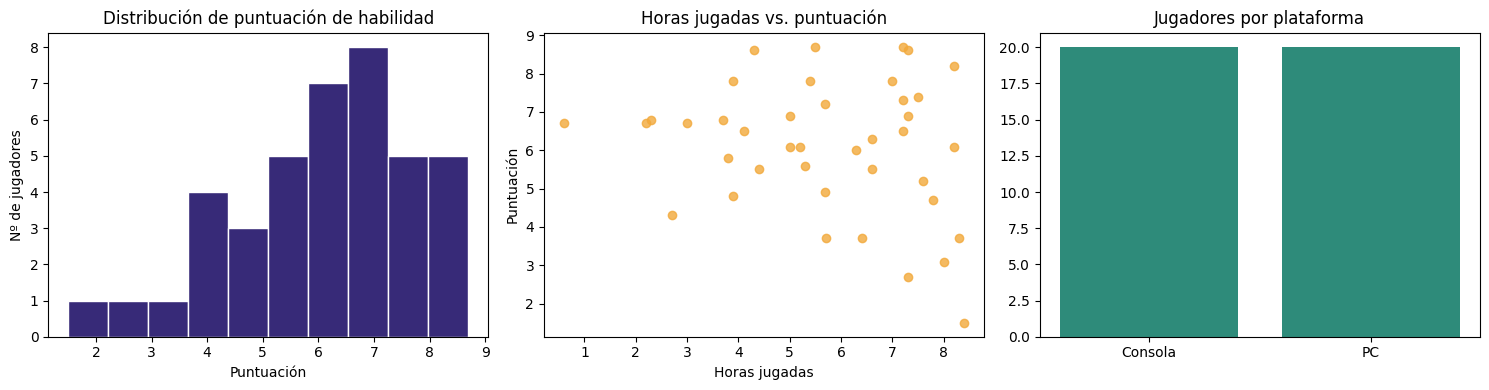

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_limpio["puntuacion"], bins=10, color="#372A78", edgecolor="white")
axes[0].set_title("Distribución de puntuación de habilidad")
axes[0].set_xlabel("Puntuación")
axes[0].set_ylabel("Nº de jugadores")

axes[1].scatter(df_limpio["horas_jugadas"], df_limpio["puntuacion"], color="#F2A93B", alpha=0.8)
axes[1].set_title("Horas jugadas vs. puntuación")
axes[1].set_xlabel("Horas jugadas")
axes[1].set_ylabel("Puntuación")

conteo = df_limpio["plataforma"].value_counts()
axes[2].bar(conteo.index, conteo.values, color="#2E8B7A")
axes[2].set_title("Jugadores por plataforma")

plt.tight_layout()
plt.show()


## 5 · Reto integrador

Encadena tú solo/a los tres pasos: carga (ya la tenemos en `df`), limpieza y una gráfica que responda a una pregunta concreta. Completa las líneas marcadas con `# TODO`.

Puntuación media en Consola: 6.22


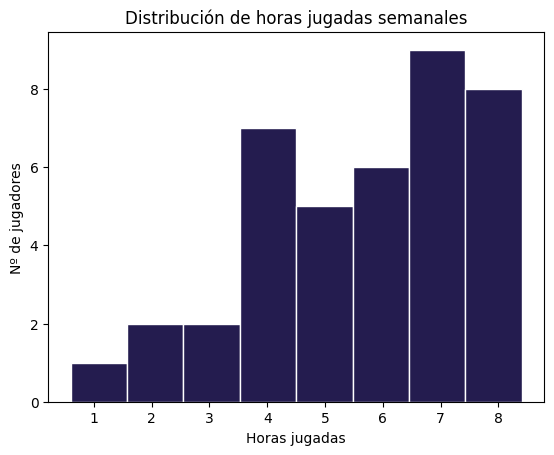

In [30]:
# TODO: ¿cuál es la puntuación media en Consola, una vez limpiado el dataset?
puntuacion_media_consola = df_codificado[df_codificado["plataforma_Consola"] == True]["puntuacion"].mean()
print(f"Puntuación media en Consola: {round(puntuacion_media_consola, 2)}")

# TODO: dibuja un histograma solo de las horas jugadas
plt.hist(df_limpio["horas_jugadas"], bins=8, color="#241C4F", edgecolor="white")
plt.title("Distribución de horas jugadas semanales")
plt.xlabel("Horas jugadas")
plt.ylabel("Nº de jugadores")
plt.show()


## 6 · Primer vistazo a Scikit-learn

Todavía no hemos visto la teoría (eso llega en UT3), pero sí podemos ver el patrón de código que vas a repetir con casi cualquier modelo: `fit()` para entrenar, `predict()` para predecir.

### Separar en entrenamiento y prueba

Antes de entrenar, reservamos una parte de los datos ("test") que el modelo no verá durante el entrenamiento — así podemos comprobar si de verdad generaliza.

In [31]:
from sklearn.model_selection import train_test_split

X = df_limpio[["horas_jugadas"]]
y = df_limpio["puntuacion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Filas de entrenamiento:", len(X_train), " · Filas de prueba:", len(X_test))


Filas de entrenamiento: 32  · Filas de prueba: 8


In [32]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)                    # entrena solo con los datos de entrenamiento

horas_nuevas = pd.DataFrame({"horas_jugadas": [2, 6, 10]})
predicciones = modelo.predict(horas_nuevas)

for h, p in zip(horas_nuevas["horas_jugadas"], predicciones):
    print(f"Con {h}h jugadas, el modelo predice una puntuación de {round(p, 2)}")

print("R² sobre los datos de prueba (no vistos en el entrenamiento):", round(modelo.score(X_test, y_test), 3))


Con 2h jugadas, el modelo predice una puntuación de 6.92
Con 6h jugadas, el modelo predice una puntuación de 5.89
Con 10h jugadas, el modelo predice una puntuación de 4.87
R² sobre los datos de prueba (no vistos en el entrenamiento): -0.776


No te preocupes si `fit`/`predict` todavía no te dice mucho — es exactamente el patrón que vamos a diseccionar desde cero al empezar UT3 (Aprendizaje supervisado). Aquí solo queríamos que el código no te resultara extraño el primer día.

---
**Resumen de lo practicado:** arrays y filtrado con NumPy · carga y exploración con Pandas (`head`, `info`, `describe`) · limpieza (nulos, duplicados, `get_dummies`) · tres gráficas básicas con Matplotlib · primer `fit`/`predict` con Scikit-learn.

## 7 · Adelanto del proyecto: de texto a una tabla de características

En la semana 7 arranca el proyecto en equipo, y uno de los dos que puedes elegir es **"¿Lo escribió una IA?"** — un clasificador de texto humano vs. generado por IA. Antes de entrenar nada (eso llega en UT3), el primer paso es el mismo que acabas de practicar con `jugadores.csv`: convertir texto libre en filas y columnas de números.

Aviso: el dataset de abajo son diez sinopsis breves **inventadas** para practicar la técnica, con una etiqueta de origen puesta a propósito — no es un dataset real de detección de IA.

In [33]:
textos = [
    {"titulo": "Stranger Things",  "sinopsis": "Un grupo de críos de un pueblo perdido se topa con monstruos, portales y unos militares muy turbios. Te enganchas por la nostalgia ochentera, no te voy a mentir.", "origen": "humano"},
    {"titulo": "El Juego del Calamar", "sinopsis": "Gente hasta arriba de deudas juega a juegos infantiles... por su vida. Es durísima y a la vez no puedes dejar de verla.", "origen": "humano"},
    {"titulo": "La Casa de Papel", "sinopsis": "Un atraco imposible, una banda con nombres de ciudades y el Profesor liándola parda desde el primer minuto. Viciante total.", "origen": "humano"},
    {"titulo": "Wednesday",        "sinopsis": "La hija de los Addams en un instituto para rarones, resolviendo un misterio con esa cara de póker que ya es un meme.", "origen": "humano"},
    {"titulo": "The Bear",         "sinopsis": "Un cocinero de restaurante top vuelve al bareto de su familia hecho un caos, con la cocina ardiendo literal y figuradamente.", "origen": "humano"},
    {"titulo": "Bridgerton",       "sinopsis": "Serie ambientada en la alta sociedad londinense que explora las relaciones amorosas, las expectativas familiares y las normas sociales de la época.", "origen": "IA"},
    {"titulo": "House of the Dragon", "sinopsis": "Producción de fantasía que narra los conflictos de poder dentro de una familia real, abordando temas de sucesión, lealtad y estrategia política.", "origen": "IA"},
    {"titulo": "Only Murders in the Building", "sinopsis": "Comedia de misterio centrada en tres vecinos de un edificio que deciden investigar un crimen, combinando suspense con un tono ligero y humorístico.", "origen": "IA"},
    {"titulo": "Ted Lasso",        "sinopsis": "Serie de comedia que sigue a un entrenador de fútbol trasladado a Inglaterra, centrada en el optimismo, el trabajo en equipo y el desarrollo personal.", "origen": "IA"},
    {"titulo": "Rick and Morty",   "sinopsis": "Serie de animación centrada en las aventuras interdimensionales de un científico excéntrico y su nieto, combinando humor absurdo con reflexiones sobre la ciencia.", "origen": "IA"},
]

df_textos = pd.DataFrame(textos)
df_textos.head()

,titulo,sinopsis,origen
0,Stranger Things,Un grupo de críos de un pueblo perdido se topa...,humano
1,El Juego del Calamar,Gente hasta arriba de deudas juega a juegos in...,humano
2,La Casa de Papel,"Un atraco imposible, una banda con nombres de ...",humano
3,Wednesday,La hija de los Addams en un instituto para rar...,humano
4,The Bear,Un cocinero de restaurante top vuelve al baret...,humano


### Ingeniería de características

Las mismas herramientas de siempre — funciones de texto de Python aplicadas columna a columna con Pandas.

In [34]:
df_textos["num_caracteres"] = df_textos["sinopsis"].str.len()
df_textos["num_palabras"] = df_textos["sinopsis"].str.split().str.len()
df_textos["num_exclamaciones"] = df_textos["sinopsis"].str.count("!")

# diversidad léxica: palabras distintas / total de palabras
df_textos["diversidad_lexica"] = df_textos["sinopsis"].apply(
    lambda texto: len(set(texto.lower().split())) / len(texto.split())
)

df_textos[["titulo", "num_caracteres", "num_palabras", "num_exclamaciones", "diversidad_lexica"]]

,titulo,num_caracteres,num_palabras,num_exclamaciones,diversidad_lexica
0,Stranger Things,161,29,0,0.896552
1,El Juego del Calamar,119,23,0,0.913043
2,La Casa de Papel,123,20,0,0.950000
3,Wednesday,116,23,0,0.869565
4,The Bear,124,21,0,0.904762
5,Bridgerton,147,22,0,0.863636
6,House of the Dragon,144,22,0,0.863636
7,Only Murders in the Building,147,23,0,0.869565
8,Ted Lasso,150,25,0,0.800000
9,Rick and Morty,162,23,0,0.956522


### ¿Hay diferencia entre "humano" e "IA" en este ejemplo?

In [35]:
df_textos.groupby("origen")[["num_palabras", "num_exclamaciones", "diversidad_lexica"]].mean()
# con solo 10 filas esto es solo para practicar el proceso, no una conclusión real

,num_palabras,num_exclamaciones,diversidad_lexica
origen,,,
IA,23.0,0.0,0.870672
humano,23.2,0.0,0.906784


**Reto rápido:** añade una característica nueva propia (por ejemplo, longitud media de palabra, o número de comas) y comprueba si separa mejor o peor los dos grupos que `diversidad_lexica`.

In [36]:
# Solución de ejemplo: longitud media de palabra
df_textos["longitud_media_palabra"] = df_textos["sinopsis"].str.split().apply(
    lambda palabras: sum(len(p) for p in palabras) / len(palabras)
)
df_textos.groupby("origen")["longitud_media_palabra"].mean()

origen
IA        5.575984
humano    4.608587
Name: longitud_media_palabra, dtype: float64

No hemos entrenado ningún modelo todavía — eso es justo lo que veremos en UT3 con `train_test_split` + `fit`/`predict`, aplicado a una tabla de características como esta en vez de a las frases sueltas.